# EDA - Competitive Price Forecasting

In [21]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, StrMethodFormatter
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf



## Chain Campaigns Dataset

In [2]:
df = pd.read_csv("train/chain_campaigns.csv")

In [3]:
df.head()

,competitor,start_date,end_date,chain_campaign
0,chain,2024-08-12,2024-08-18,C2
1,competitorA,2023-09-22,2023-09-25,A2
2,chain,2024-09-23,2024-09-29,C1
3,chain,2024-04-08,2024-04-14,C1
4,competitorA,2023-10-20,2023-10-23,A2


In [11]:
# Convert dates
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

# Compute duration of campaigns
df['duration_days'] = (df['end_date'] - df['start_date']).dt.days + 1
skewness = df['duration_days'].skew()

In [68]:
df.head()

,competitor,start_date,end_date,chain_campaign,duration_days
0,chain,2024-08-12,2024-08-18,C2,7
1,competitorA,2023-09-22,2023-09-25,A2,4
2,chain,2024-09-23,2024-09-29,C1,7
3,chain,2024-04-08,2024-04-14,C1,7
4,competitorA,2023-10-20,2023-10-23,A2,4


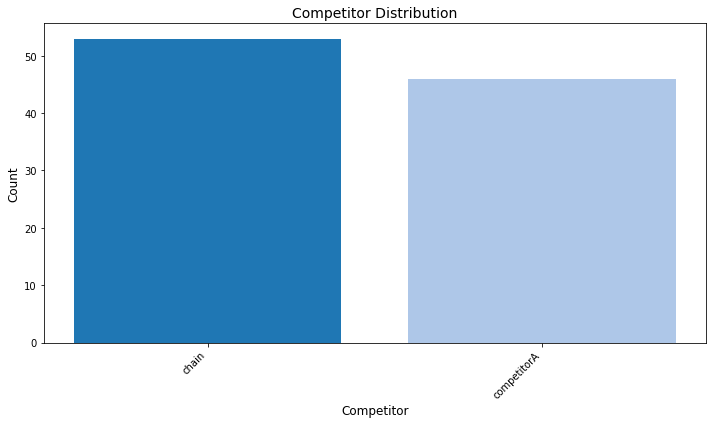

In [ ]:
# Competitor distribution

counts = df['competitor'].value_counts() #get competitor values

colors = plt.cm.tab20.colors[:len(counts)]

#graph
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color=colors)
plt.title("Competitor Distribution", fontsize=14)
plt.xlabel("Competitor", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

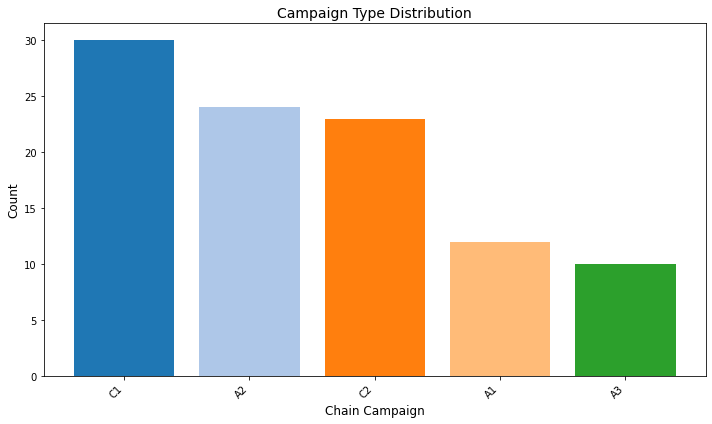

In [7]:
# Campaign type distribution

counts = df['chain_campaign'].value_counts()

colors = plt.cm.tab20.colors[:len(counts)]

#graph
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color=colors)
plt.title("Campaign Type Distribution", fontsize=14)
plt.xlabel("Chain Campaign", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

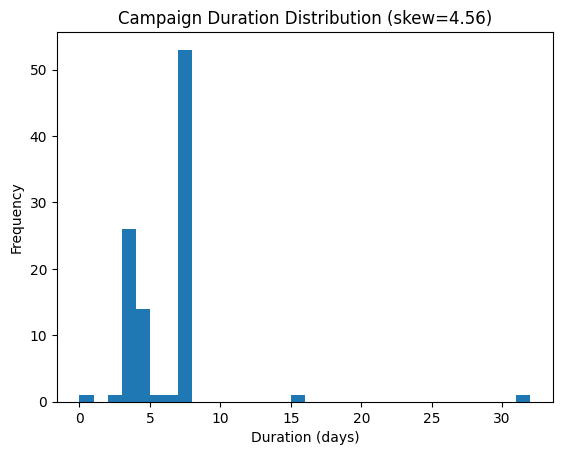

In [ ]:
# Histogram of campaign durations

plt.figure()
plt.hist(df['duration_days'], bins=range(df['duration_days'].min(), df['duration_days'].max() + 2))
plt.title(f"Campaign Duration Distribution (skew={skewness:.2f})")
plt.xlabel("Duration (days)")
plt.ylabel("Frequency")
plt.tight_layout()

In [8]:
# Outliers
Q1, Q3 = df['duration_days'].quantile([0.25, 0.75])
IQR   = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers_overall = df[(df['duration_days'] < lower) | (df['duration_days'] > upper)]
print("Overall Duration Outliers:")
outliers_overall.head()

Overall Duration Outliers:


,competitor,start_date,end_date,chain_campaign,duration_days
45,competitorA,2024-03-01,2024-03-31,A2,31
91,competitorA,2023-07-06,2023-07-20,A1,15


In [ ]:
df.chain_campaign.unique() #check unique values of chain_campaign variable

array(['C2', 'A2', 'C1', 'A3', 'A1'], dtype=object)

In [ ]:
df.duplicated().sum() #check duplicated data

np.int64(0)

In [ ]:
df.nunique() #check unique valaues of the campaign dataset

competitor         2
start_date        97
end_date          86
chain_campaign     5
dtype: int64

In [ ]:
df.isnull().sum() #check missing values

competitor        0
start_date        0
end_date          0
chain_campaign    0
dtype: int64

In [ ]:
### Time Series - feature engineering to create new variables according to the campaign dates

new = pd.DataFrame()
new['date'] = df['start_date'] 
new['day'] = new['date'].dt.day
new['month'] = new['date'].dt.month
new['year'] = new['date'].dt.year
new['day of the week'] = new['date'].dt.weekday
new['day of the week name'] = new['date'].dt.day_name()
new['quarter'] = new['date'].dt.quarter
new['is it a leap year?'] = new['date'].dt.is_leap_year

new.head(2)

In [5]:
df.isnull().sum() #check missing values

competitor        0
start_date        0
end_date          0
chain_campaign    0
dtype: int64

In [5]:
df.dtypes #check data types of each column/variable

competitor        object
start_date        object
end_date          object
chain_campaign    object
dtype: object

In [17]:
# Campaign Duration

s_min = df['start_date'].min().strftime('%d-%m-%Y')
s_max = df['start_date'].max().strftime('%d-%m-%Y')

print(f"Start Date: from {s_min} until {s_max}")

e_min = df['end_date'].min().strftime('%d-%m-%Y')
e_max = df['end_date'].max().strftime('%d-%m-%Y')

print(f"End Date: from {e_min} until {e_max}")



Start Date: from 03-01-2023 until 25-10-2024
End Date: from 09-01-2023 until 27-10-2024


## Product Prices Leaflets Dataset

In [18]:
df_prices = pd.read_csv("train/product_prices_leaflets.csv")
df_prices.head()

,sku,time_key,competitor,pvp_was,discount,flag_promo,leaflet
0,2056,20240312,chain,21.70,0.0000,0,NaN
1,4435,20230621,chain,18.92,0.2754,1,weekly
2,1951,20230303,competitorA,60.58,0.3524,1,NaN
3,2135,20240605,chain,55.37,0.2509,1,weekly
4,3949,20230529,chain,51.90,0.0000,0,NaN


In [5]:
df_prices.leaflet.unique()

array([nan, 'weekly', 'short', 'themed'], dtype=object)

In [ ]:
df_prices['time_key'] = pd.to_datetime(df_prices['time_key'].astype(str), format='%Y%m%d')
df_prices.head()

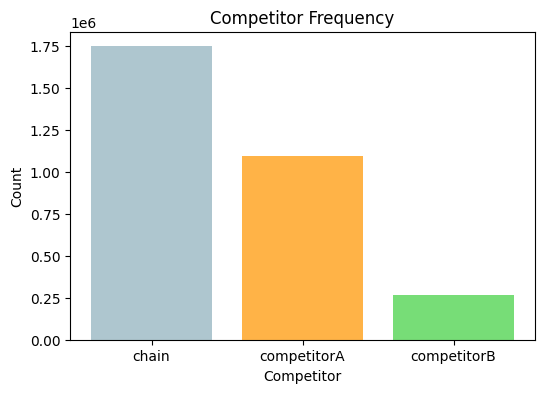

In [ ]:
# Bar chart - Competitor Frequency

plt.figure(figsize=(6, 4))

colors_pastel = ['#AEC6CF',  # light blue
                 '#FFB347',  # light orange
                 '#77DD77']  # light green

counts_comp = df_prices['competitor'].value_counts(dropna=False)
plt.bar(counts_comp.index, counts_comp.values, color=colors_pastel)
plt.title('Competitor Frequency')
plt.xlabel('Competitor')
plt.ylabel('Count')
plt.show()

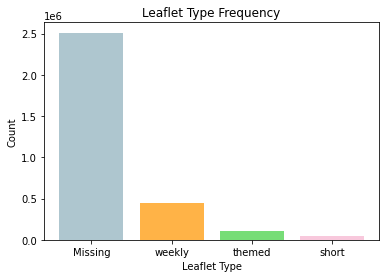

In [23]:
# Bar chart - Leaflet Type Frequency
plt.figure(figsize=(6, 4))

pastels = [
    "#AEC6CF", 
    "#FFB347",  
    "#77DD77",  
    "#F8C8DC",  
]

counts_leaf = df_prices['leaflet'].fillna('Missing').value_counts()
plt.bar(counts_leaf.index, counts_leaf.values, color=pastels)
plt.title('Leaflet Type Frequency')
plt.xlabel('Leaflet Type')
plt.ylabel('Count')
plt.show()

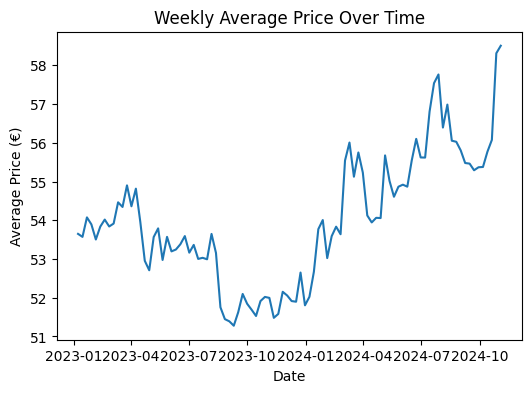

In [ ]:
# Time series: weekly average price

weekly_avg = df_prices.set_index('time_key').resample('W')['pvp_was'].mean()
plt.figure(figsize=(6, 4))
plt.plot(weekly_avg.index, weekly_avg.values)
plt.title('Weekly Average Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price (€)')
plt.show()

<Axes: >

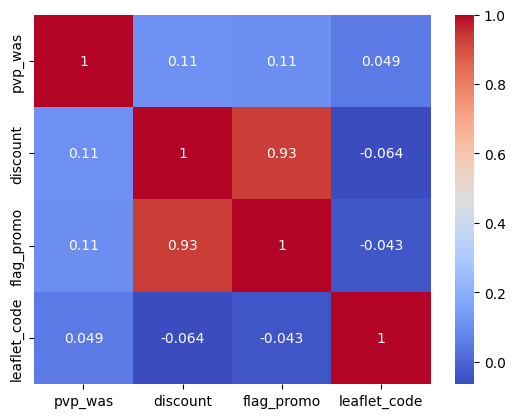

In [ ]:
# Correlation Matrix without sku and time_key features

# Encode leaflet
mapping = {'weekly':0, 'short':1, 'themed':2}
df_prices['leaflet_code'] = df_prices['leaflet'].map(mapping)

# Drop non‑numeric / id cols
to_corr = df_prices[['pvp_was','discount','flag_promo','leaflet_code']]

# Plot correlation matrix
corr = to_corr.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [136]:
drop_corr = ['sku', 'time_key', 'competitor', 'leaflet', 'day_of_week', 'week_of_year', 'month', 'day_of_month', 'is_month_end', 'days_since_start']

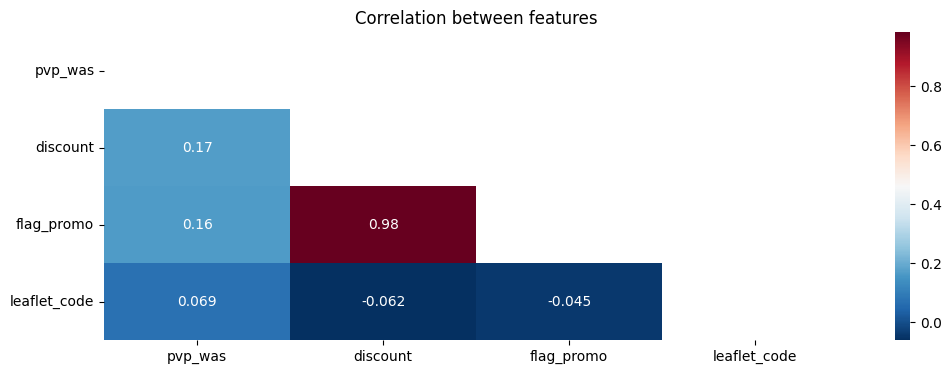

In [ ]:
# Correlation Matrix - Lower Triangle

corr_matrix = df_prices.drop(drop_corr, axis=1).corr(method='spearman')
corr_matrix

lower_triangle_mask = np.triu(np.ones(corr_matrix.shape)).astype(bool)
cor_mat_lower = corr_matrix.mask(lower_triangle_mask)

plt.figure(figsize = (12,4))
plt.title("Correlation between features")

sns.heatmap(cor_mat_lower, 
            annot=True,
            cmap='RdBu_r');

In [138]:
drop_corr_no_times = ['sku', 'time_key', 'competitor', 'leaflet']

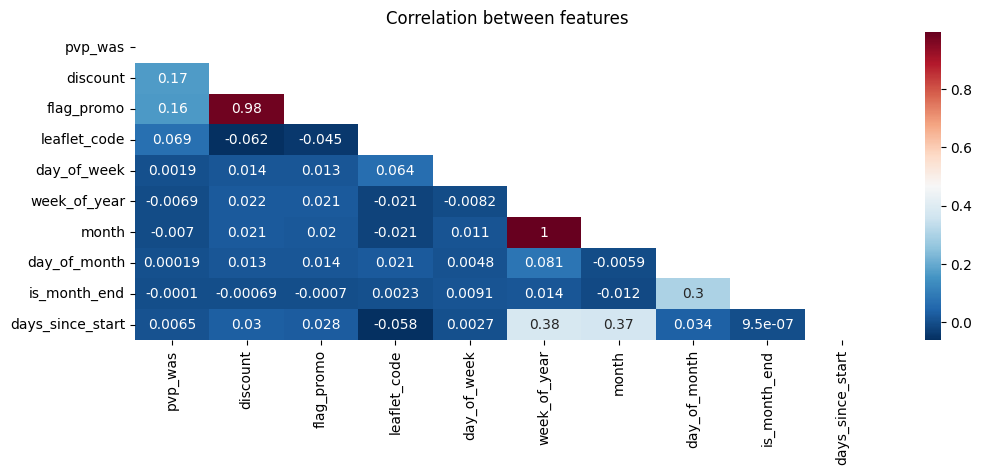

In [ ]:
# Correlation Matrix - Lower Triangle

corr_matrix = df_prices.drop(drop_corr_no_times, axis=1).corr(method='spearman')
corr_matrix

lower_triangle_mask = np.triu(np.ones(corr_matrix.shape)).astype(bool)
cor_mat_lower = corr_matrix.mask(lower_triangle_mask)

plt.figure(figsize = (12,4))
plt.title("Correlation between features")

sns.heatmap(cor_mat_lower, 
            annot=True,
            cmap='RdBu_r');

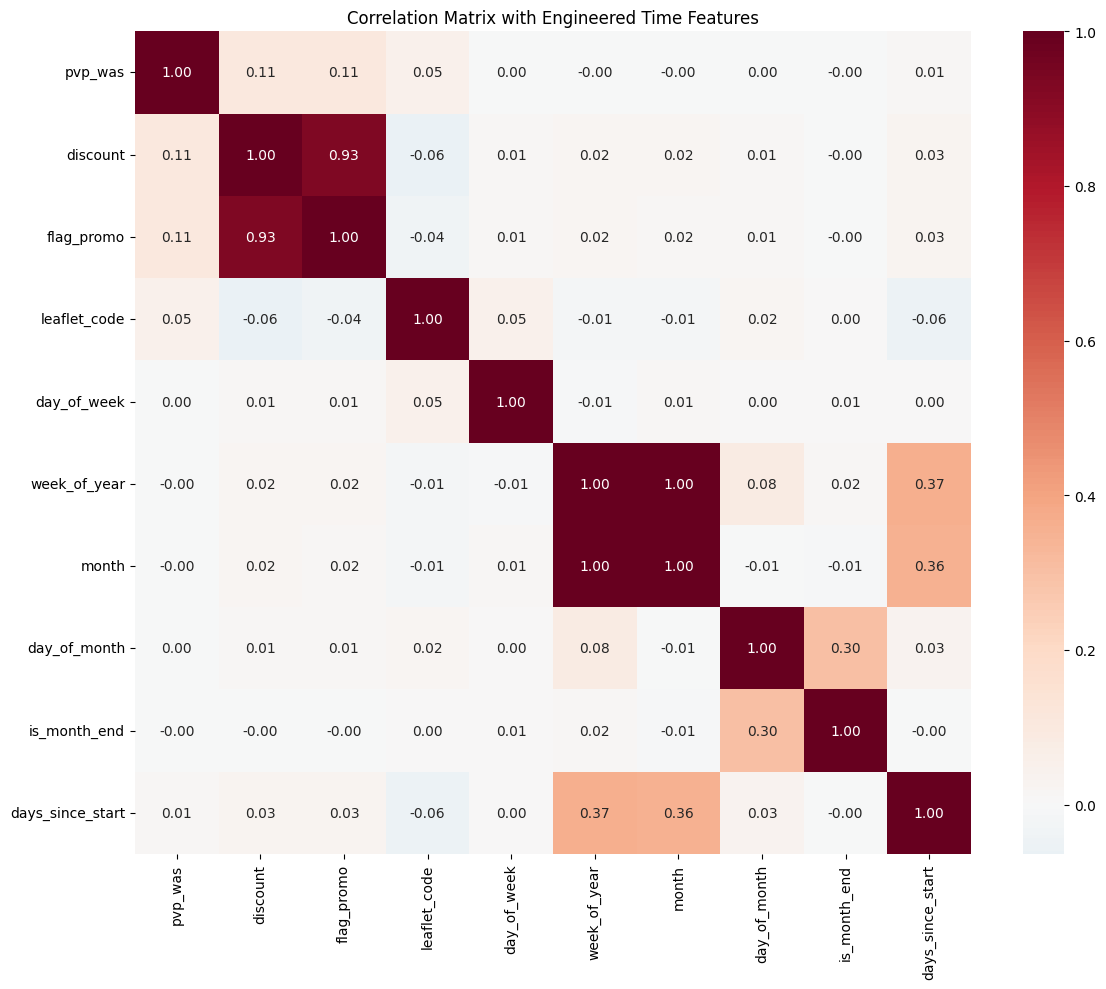

In [ ]:
### correlation matrix with time_key feature (day of week, month, etc)

# 1. Convert time_key to datetime and sort
df_prices = df_prices.sort_values('time_key')

# 2. Extract time-based features
df_prices['day_of_week'] = df_prices['time_key'].dt.dayofweek      # 0 = Monday, 6 = Sunday
df_prices['week_of_year'] = df_prices['time_key'].dt.isocalendar().week
df_prices['month'] = df_prices['time_key'].dt.month
df_prices['day_of_month'] = df_prices['time_key'].dt.day
df_prices['is_month_end'] = df_prices['time_key'].dt.is_month_end.astype(int)
df_prices['days_since_start'] = (df_prices['time_key'] - df_prices['time_key'].min()).dt.days



In [ ]:
negative_count = (df_prices['discount'] < 0).sum() # Count negative entries --> considered data errors
print(negative_count)

40


In [ ]:
# Total non-missing entries
total_count = df_prices['discount'].notna().sum()
print(total_count)

# Percentage of negatives
neg_pct = negative_count / total_count * 100
print(neg_pct)

3112140
0.0012852892222072272


In [ ]:
# Descriptive Statistics of df_prices dataframe
df_prices.describe() 

,sku,time_key,pvp_was,discount,flag_promo
count,3.112140e+06,3.112140e+06,3.112140e+06,3.112140e+06,3.112140e+06
mean,3.171605e+03,2.023514e+07,5.397732e+01,6.569260e-02,2.449617e-01
std,9.778981e+02,4.935283e+03,6.324775e+01,1.235808e-01,4.300645e-01
min,1.128000e+03,2.023010e+07,3.990000e+00,-2.030700e+00,0.000000e+00
25%,2.351000e+03,2.023062e+07,2.673000e+01,0.000000e+00,0.000000e+00
50%,3.242000e+03,2.023113e+07,3.975000e+01,0.000000e+00,0.000000e+00
75%,4.025000e+03,2.024051e+07,5.710000e+01,0.000000e+00,0.000000e+00
max,4.735000e+03,2.024103e+07,1.084640e+03,9.255000e-01,1.000000e+00


In [141]:
# Select only the continuous columns
to_check = ['pvp_was', 'discount']

# Calculate skewness
skews = df_prices[to_check].skew()
print("Skewness of continuous variables:\n", skews)

# If any skew > |1|, consider a log1p transform:
for col in to_check:
    print(f"{col} skew before:", df_prices[col].skew())
    df_prices[f"log1p_{col}"] = np.log1p(df_prices[col].clip(lower=0))
    print(f"{col} skew after :", df_prices[f"log1p_{col}"].skew(), "\n")

Skewness of continuous variables:
 pvp_was     5.894885
discount    1.618131
dtype: float64
pvp_was skew before: 5.8948851084959975
pvp_was skew after : 0.8064117662505588 

discount skew before: 1.6181312774982726
discount skew after : 1.5363167707449508 



In [ ]:
df_clean_prices = df_prices.copy()

# Keep only rows where discount variable is ≥ 0 (positive)
df_clean_prices = df_clean_prices[df_clean_prices['discount'] >= 0]


In [9]:
desc = df_clean_prices['pvp_was'].describe()
print(desc)

count    3.112100e+06
mean     5.397754e+01
std      6.324810e+01
min      3.990000e+00
25%      2.673000e+01
50%      3.975000e+01
75%      5.710000e+01
max      1.084640e+03
Name: pvp_was, dtype: float64


In [16]:
df_clean_prices.head()

,sku,time_key,competitor,pvp_was,discount,flag_promo,leaflet
0,2056,20240312,chain,21.70,0.0000,0,NaN
1,4435,20230621,chain,18.92,0.2754,1,weekly
2,1951,20230303,competitorA,60.58,0.3524,1,NaN
3,2135,20240605,chain,55.37,0.2509,1,weekly
4,3949,20230529,chain,51.90,0.0000,0,NaN


In [ ]:
# Count when promo is zero

is_zero = df_clean_prices['flag_promo'] != 0

zero_count = is_zero.sum()

zero_pct = is_zero.mean() * 100

print(f"NonZero‐promo count: {zero_count}")
print(f"NonZero‐promo percentage: {zero_pct:.2f}%")

NonZero‐promo count: 762355
NonZero‐promo percentage: 24.50%


In [23]:
promo_stats = (
    df_clean_prices
    .groupby('competitor')['flag_promo']
    .agg(
        total_records='count',
        promo_count=lambda x: x.sum()
    )
    .assign(
        promo_pct=lambda d: d['promo_count'] / d['total_records'] * 100
    )
)

print(promo_stats)

             total_records  promo_count  promo_pct
competitor                                        
chain              1749087       512413  29.296027
competitorA        1094290       223642  20.437178
competitorB         268723        26300   9.787030


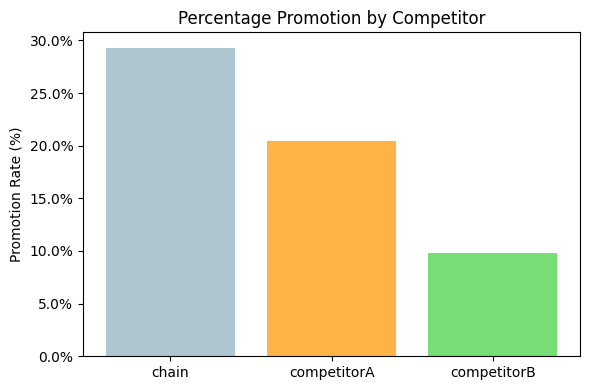

In [ ]:
# Percentage of Promotion by Competitor

from matplotlib.ticker import PercentFormatter

pastels = [
    "#AEC6CF", 
    "#FFB347",  
    "#77DD77",  
    "#F8C8DC",  
]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(promo_stats.index, promo_stats['promo_pct'], color=pastels)
ax.set_ylabel('Promotion Rate (%)')
ax.set_title('Percentage Promotion by Competitor')
ax.yaxis.set_major_formatter(PercentFormatter())
plt.tight_layout()
plt.show()

In [ ]:
# Compute average price per competitor
mean_prices = df_prices.groupby('competitor')['pvp_was'].mean()

# Sort to see ranking
mean_prices_sorted = mean_prices.sort_values(ascending=False)
print("Average price by competitor (highest→lowest):\n", mean_prices_sorted)

# Identify the extremes
highest = mean_prices.idxmax()
cheapest = mean_prices.idxmin()
print(f"\nHighest‐price competitor: {highest} (avg. {mean_prices[highest]:.2f})")
print(f"Cheapest competitor: {cheapest}   (avg. {mean_prices[cheapest]:.2f})")

Average price by competitor (highest→lowest):
 competitor
chain          58.420702
competitorA    50.730012
competitorB    38.281888
Name: pvp_was, dtype: float64

Highest‐price competitor: chain (avg. 58.42)
Cheapest competitor: competitorB   (avg. 38.28)


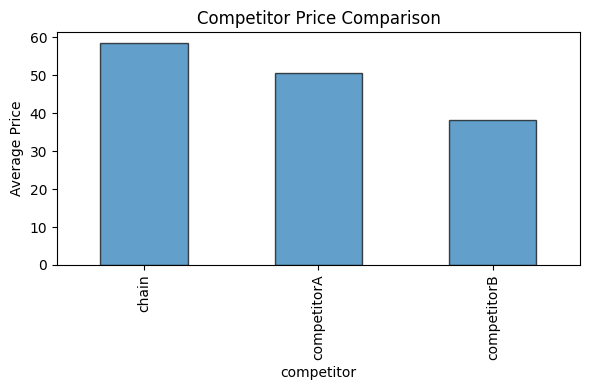

In [ ]:
# Compare average prices per competitor

mean_prices_sorted.plot(kind='bar', figsize=(6,4), edgecolor='black', alpha=0.7)
plt.ylabel('Average Price')
plt.title('Competitor Price Comparison')
plt.tight_layout()
plt.show()

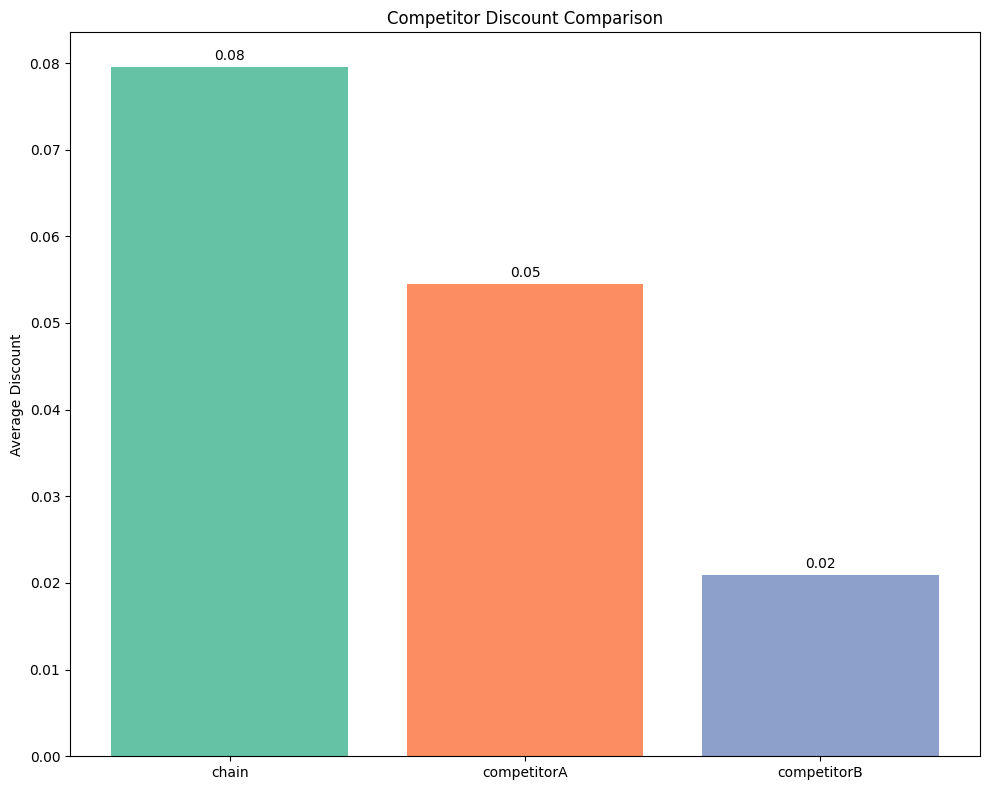

In [ ]:
# Compare average discounts applied per competitor

# Compute mean prices per competitor and sort
mean_prices_sorted = df_prices.groupby('competitor')['discount'].mean().sort_values(ascending=False)

# Choose a qualitative colormap for distinct colors
cmap = plt.get_cmap('Set2')                # you can also try 'Set2', 'Accent', etc.
colors = cmap(np.arange(len(mean_prices_sorted)))  # one color per bar

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.bar(mean_prices_sorted.index, 
              mean_prices_sorted.values,
              color=colors)
ax.set_ylabel('Average Discount')
ax.set_title('Competitor Discount Comparison')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',                
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),                 
                textcoords='offset points',
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

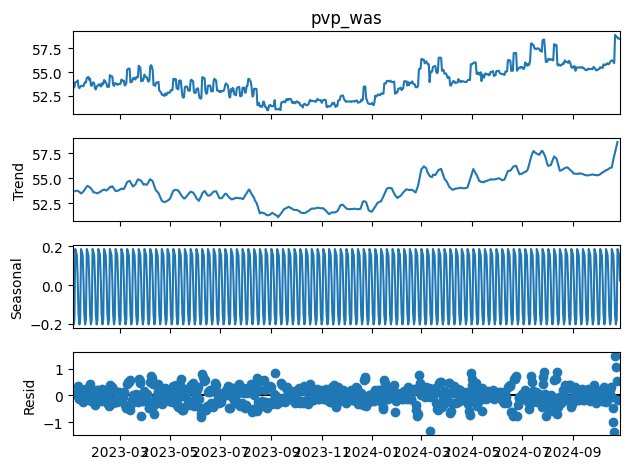

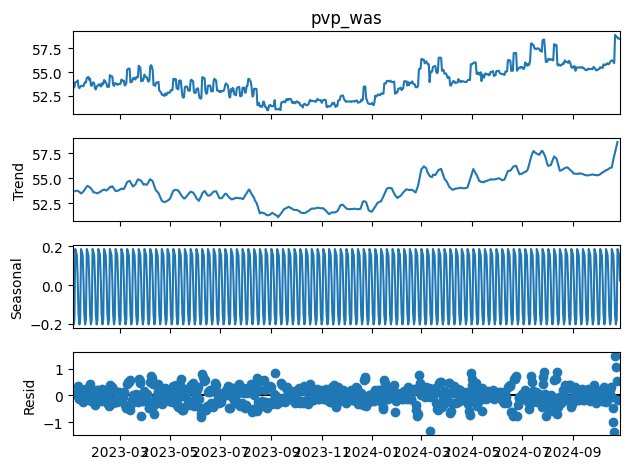

In [ ]:
# Check price seasonality

daily = df_prices.set_index('time_key')['pvp_was'].resample('D').mean().ffill()
result = seasonal_decompose(daily, model='additive', period=7)
result.plot()

In [ ]:
df_prices.duplicated().sum() #check duplicated data

np.int64(0)

In [20]:
df_prices_copy = df_prices.copy()

In [9]:
df_prices.shape

(3112140, 7)

In [ ]:
df_prices.duplicated().sum() #check duplicated data

np.int64(0)

In [ ]:
# Feature Engineer Target variable --> Effective Selling Price

df_price_with_target = df_prices_copy.copy()
df_price_with_target['effective_selling_price'] = df_price_with_target['pvp_was'] * (1 - df_price_with_target['discount'])
df_price_with_target.head()

,sku,time_key,competitor,pvp_was,discount,flag_promo,leaflet,effective_selling_price
0,2056,20240312,chain,21.70,0.0000,0,NaN,21.700000
1,4435,20230621,chain,18.92,0.2754,1,weekly,13.709432
2,1951,20230303,competitorA,60.58,0.3524,1,NaN,39.231608
3,2135,20240605,chain,55.37,0.2509,1,weekly,41.477667
4,3949,20230529,chain,51.90,0.0000,0,NaN,51.900000


In [ ]:
# Remove leaflet column since 81% of its data is MISSING (for modelling)
df_price_with_target = df_price_with_target.drop('leaflet', axis=1)

In [24]:
df_price_with_target.head()

,sku,time_key,competitor,pvp_was,discount,flag_promo,effective_selling_price
0,2056,20240312,chain,21.70,0.0000,0,21.700000
1,4435,20230621,chain,18.92,0.2754,1,13.709432
2,1951,20230303,competitorA,60.58,0.3524,1,39.231608
3,2135,20240605,chain,55.37,0.2509,1,41.477667
4,3949,20230529,chain,51.90,0.0000,0,51.900000


In [ ]:
# Check target variable skewness

skew_value = df_price_with_target['effective_selling_price'].skew()
print("Skewness of the target variable:", skew_value)

Skewness of the target variable: 5.656699945034596


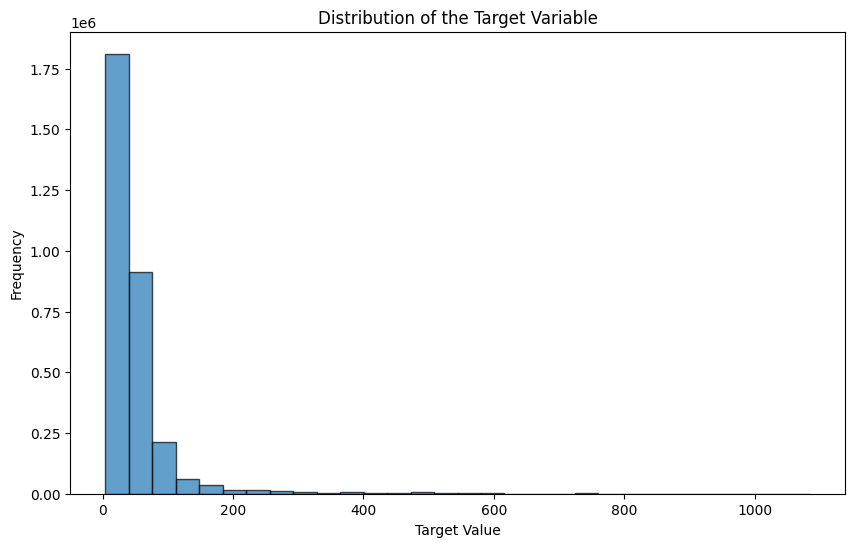

In [ ]:
# Plot distribution of the target variable

plt.figure(figsize=(10, 6))
plt.hist(df_price_with_target['effective_selling_price'], bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.title("Distribution of the Target Variable")
plt.show()

In [24]:
## Outlier analysis

# Calculate Q1, Q3, and IQR for the target variable
Q1 = df_price_with_target['effective_selling_price'].quantile(0.25)
Q3 = df_price_with_target['effective_selling_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_price_with_target[(df_price_with_target['effective_selling_price'] < lower_bound) | (df_price_with_target['effective_selling_price'] > upper_bound)]

# Visualization

# Boxplot for the target variable
plt.figure(figsize=(10, 6))
plt.boxplot(df_price_with_target['effective_selling_price'].dropna(), vert=False)
plt.title("Boxplot of Target Variable")
plt.xlabel("Target Value")
plt.show()



NameError: name 'df_price_with_target' is not defined

In [ ]:
# Separate numerical and categorical features

def separate_cat_num_feat(df: pd.DataFrame):
    # Numerical columns
    num_feats = df.select_dtypes(include=[np.number]).columns.tolist()
    # Categorical columns (object, category, bool)
    cat_feats = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    return num_feats, cat_feats

In [30]:
num_cols, cat_cols = separate_cat_num_feat(df_price_with_target)

print(num_cols)
print(cat_cols)

['sku', 'time_key', 'pvp_was', 'discount', 'flag_promo', 'effective_selling_price']
['competitor']


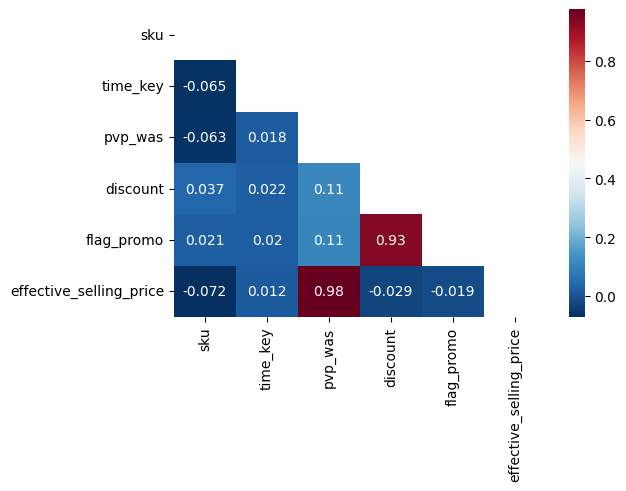

In [ ]:
# Correlation matriz of the numerical features

cor_mat = df_price_with_target[num_cols].corr() 
lower_triangle_mask = np.triu(np.ones(cor_mat.shape)).astype(bool)
cor_mat_lower = cor_mat.mask(lower_triangle_mask)

plt.figure(figsize = (6,4)) 

sns.heatmap(cor_mat_lower, 
            annot=True, 
            cmap='RdBu_r');

In [ ]:
# Check specific column range

col = 'discount'
print(f"Min: {df_prices[col].min()}")
print(f"Max: {df_prices[col].max()}")
print(f"Range: {df_prices[col].max() - df_prices[col].min()}")

Min: -2.0307
Max: 0.9255
Range: 2.9562


In [ ]:
df_prices.dtypes #check data types of the df_prices dataframe

sku             int64
time_key        int64
competitor     object
pvp_was       float64
discount      float64
flag_promo      int64
leaflet        object
dtype: object

In [ ]:
df_prices.isnull().sum() #check missing values

sku                 0
time_key            0
competitor          0
pvp_was             0
discount            0
flag_promo          0
leaflet       2510555
dtype: int64

In [ ]:
# Check missing values % for the leaflet variable

missing_percentage = df_prices['leaflet'].isnull().mean() * 100
print(f"Missing values percentage: {missing_percentage:.2f}%")

Missing values percentage: 80.67%


In [ ]:
df_prices['sku'].nunique() #check how many unique values exist for the sku variable

3561

In [ ]:
df_prices['sku'].unique()

array([2056, 4435, 1951, ..., 1159, 2206, 4205], shape=(3561,))

#### Time Series Analysis

In [ ]:
df_prices['date'] = pd.to_datetime(df_prices['time_key'], format='%Y%m%d')
df_prices = df_prices.drop(columns=['time_key'])       # remove the original column
df_prices = df_prices.set_index('date').sort_index()

In [188]:
df2 = pd.read_csv("train/product_prices_leaflets.csv")
df2['time_key'] = pd.to_datetime(df2['time_key'].astype(str), format='%Y%m%d')
df2.head()

,sku,time_key,competitor,pvp_was,discount,flag_promo,leaflet
0,2056,2024-03-12,chain,21.70,0.0000,0,NaN
1,4435,2023-06-21,chain,18.92,0.2754,1,weekly
2,1951,2023-03-03,competitorA,60.58,0.3524,1,NaN
3,2135,2024-06-05,chain,55.37,0.2509,1,weekly
4,3949,2023-05-29,chain,51.90,0.0000,0,NaN


In [190]:
daily = df2.set_index('time_key')['pvp_was'].resample('D').mean().ffill()

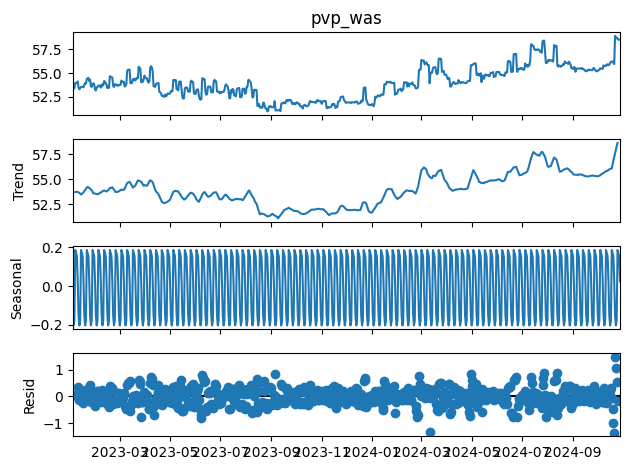

In [191]:
result = seasonal_decompose(daily, model='additive', period=7)  # weekly seasonality
result.plot()
plt.tight_layout()
plt.show()

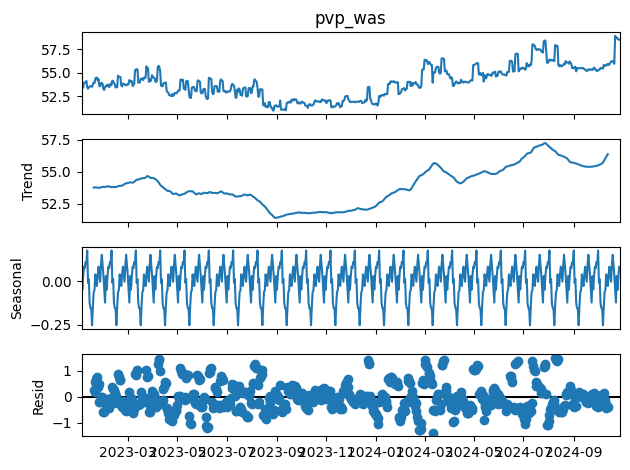

In [192]:
result = seasonal_decompose(daily, model='additive', period=30)  # monthly seasonality
result.plot()
plt.tight_layout()
plt.show()

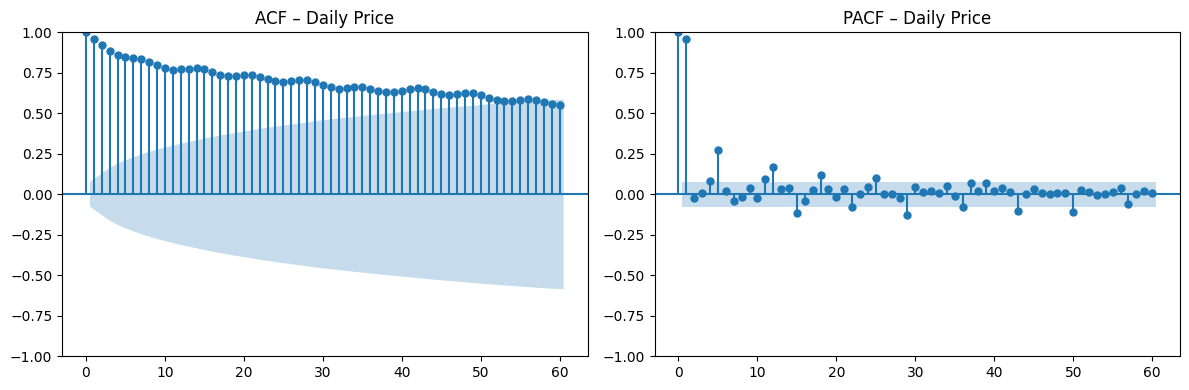

In [56]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(daily, lags=60, ax=axes[0])
plot_pacf(daily, lags=60, ax=axes[1])
axes[0].set_title("ACF – Daily Price")
axes[1].set_title("PACF – Daily Price")
plt.tight_layout()
plt.show()

/var/folders/vf/0_2jfjq96flc0cwpw0p4pch80000gn/T/ipykernel_1866/973133929.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


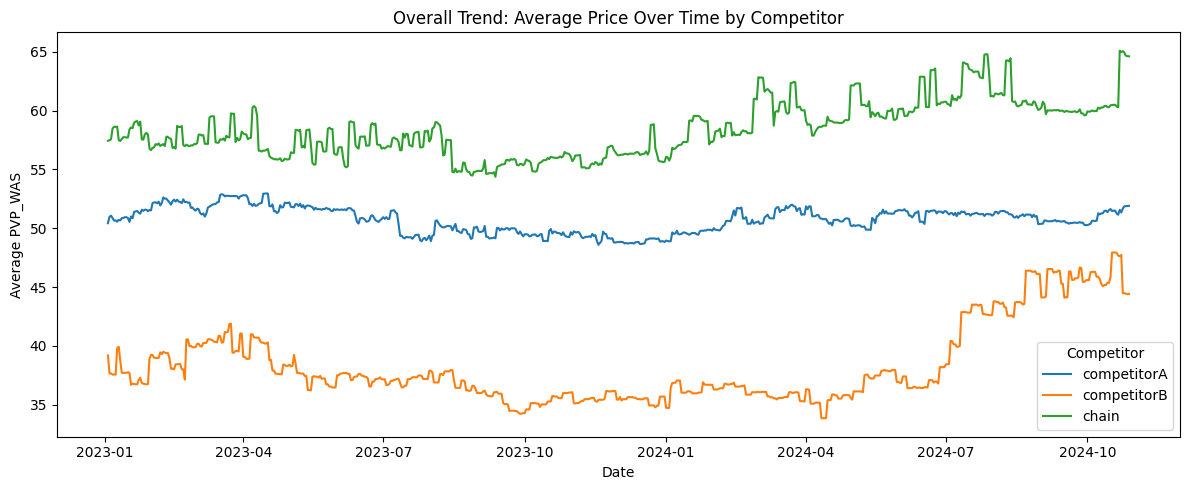

In [ ]:
## Overall Trends (mean pvp_price over time by each competitor)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_prices,
    x='date', y='pvp_was',
    hue='competitor',
    estimator='mean',
    ci=None
)
plt.title("Overall Trend: Average Price Over Time by Competitor")
plt.ylabel("Average PVP_WAS")
plt.xlabel("Date")
plt.legend(title="Competitor")
plt.tight_layout()
plt.show()

/var/folders/vf/0_2jfjq96flc0cwpw0p4pch80000gn/T/ipykernel_1866/885446355.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M').mean().reset_index()


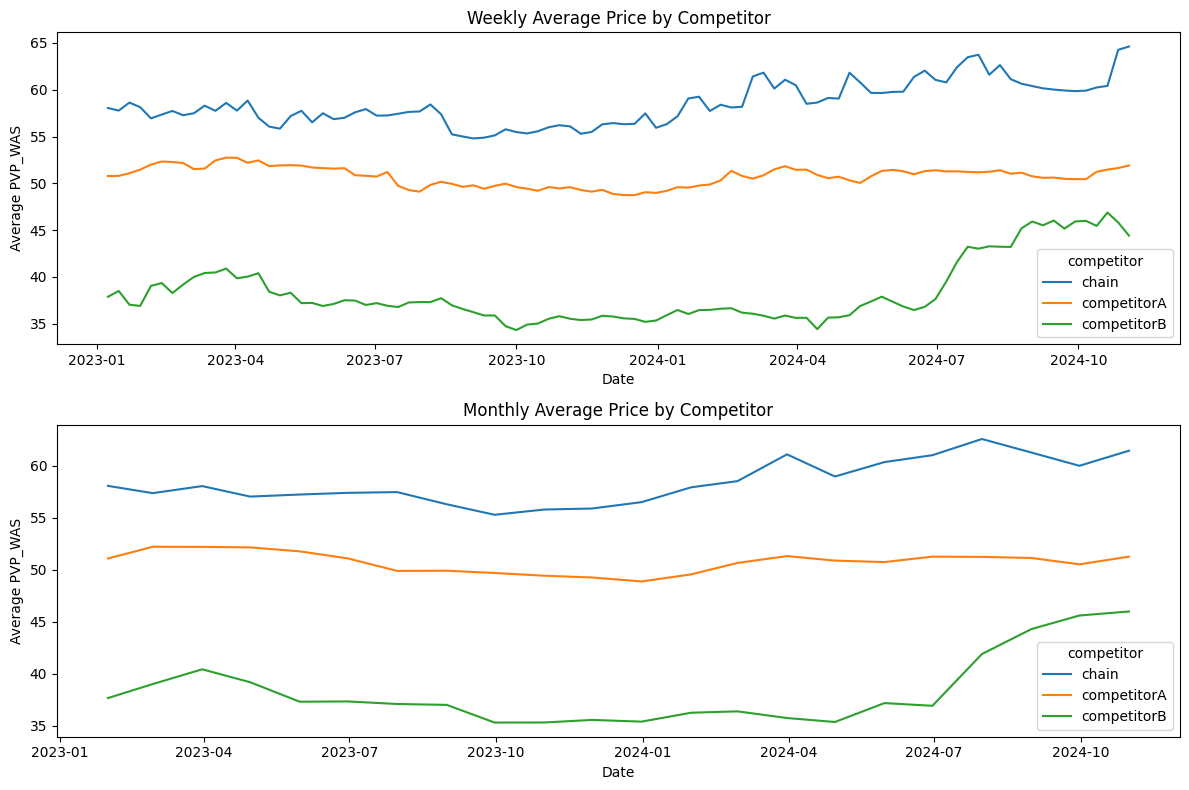

In [40]:
# Weekly resample
weekly = df_prices.set_index('date').groupby('competitor')['pvp_was'] \
               .resample('W').mean().reset_index()

# Monthly resample
monthly = df_prices.set_index('date').groupby('competitor')['pvp_was'] \
                .resample('M').mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

sns.lineplot(
    data=weekly, x='date', y='pvp_was', hue='competitor', ax=axes[0]
)
axes[0].set_title("Weekly Average Price by Competitor")

sns.lineplot(
    data=monthly, x='date', y='pvp_was', hue='competitor', ax=axes[1]
)
axes[1].set_title("Monthly Average Price by Competitor")

for ax in axes:
    ax.set_xlabel("Date")
    ax.set_ylabel("Average PVP_WAS")

plt.tight_layout()
plt.show()

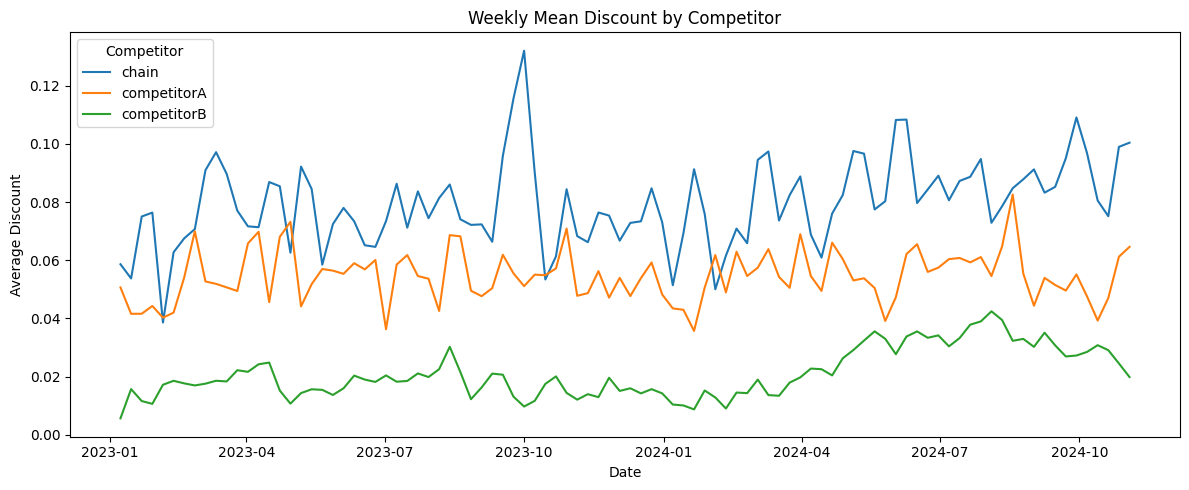

In [ ]:
## Overall Trends (mean discount over time by each competitor)

discount_trend = df_prices.set_index('date').groupby('competitor')['discount'] \
                    .resample('W').mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=discount_trend,
    x='date', y='discount',
    hue='competitor',
    estimator=None
)
plt.title("Weekly Mean Discount by Competitor")
plt.xlabel("Date")
plt.ylabel("Average Discount")
plt.legend(title="Competitor")
plt.tight_layout()
plt.show()

### Outlier detection plots

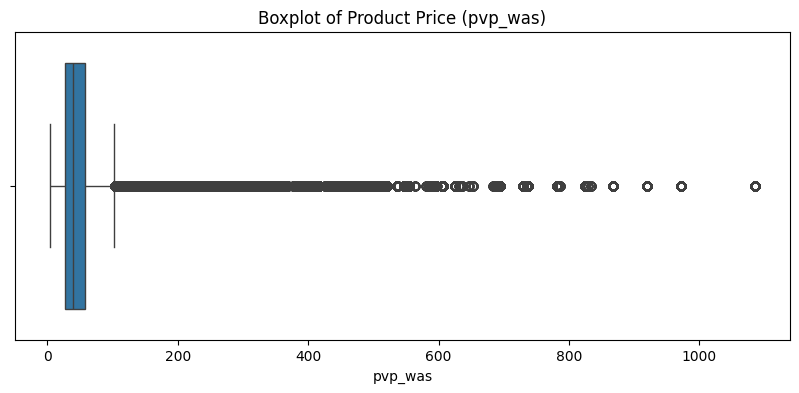

In [ ]:
# Boxplot for pvp_was (Price)
plt.figure(figsize=(10,4))
sns.boxplot(x=df2['pvp_was'])
plt.title("Boxplot of Product Price (pvp_was)")
plt.xlabel("pvp_was")
plt.show()

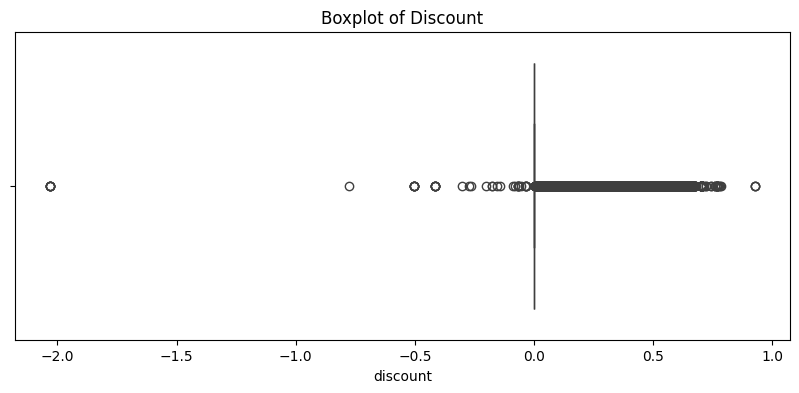

In [ ]:
# Boxplot for discount
plt.figure(figsize=(10,4))
sns.boxplot(x=df2['discount'])
plt.title("Boxplot of Discount")
plt.xlabel("discount")
plt.show()

#### Basic statistics

In [ ]:
# Summary statistics for numeric columns
print("Numeric summary:")
print(df_prices[['pvp_was', 'discount']].describe())

# Skewness and kurtosis
print("\nSkewness:")
print(df_prices[['pvp_was', 'discount']].skew())
print("\nKurtosis:")
print(df_prices[['pvp_was', 'discount']].kurtosis())

Numeric summary:
            pvp_was      discount
count  3.112140e+06  3.112140e+06
mean   5.397732e+01  6.569260e-02
std    6.324775e+01  1.235808e-01
min    3.990000e+00 -2.030700e+00
25%    2.673000e+01  0.000000e+00
50%    3.975000e+01  0.000000e+00
75%    5.710000e+01  0.000000e+00
max    1.084640e+03  9.255000e-01

Skewness:
pvp_was     5.894885
discount    1.618131
dtype: float64

Kurtosis:
pvp_was     49.454705
discount     1.514186
dtype: float64


# Product Structures Sales Dataset

In [30]:
df_sales = pd.read_csv("train/product_structures_sales.csv")
df_sales.head()

,structure_level_4,structure_level_3,structure_level_2,structure_level_1,sku,time_key,quantity
0,3020206,30202,302,3,3111,20230618,18.6840
1,3020608,30206,302,3,3278,20240731,396.1008
2,3020809,30208,302,3,3603,20230807,6.2280
3,3020608,30206,302,3,4604,20230131,27.4032
4,3040808,30408,304,3,3041,20230906,6.2280


In [31]:
df_sales.sku.nunique()

3605

In [ ]:
# Check negative values for the quantity variable --> data errors

mask_negative = (df_sales['quantity'] < 0)

n_removed = mask_negative.sum()
print(f"Dropping {n_removed} rows with negative quantity")

df_clean_sales = df_sales.loc[~mask_negative].copy()

Dropping 292 rows with negative quantity


In [ ]:
df_clean_sales.describe() #Descriptive Statistics

,structure_level_4,structure_level_3,structure_level_2,structure_level_1,sku,time_key,quantity
count,1.864302e+06,1.864302e+06,1.864302e+06,1.864302e+06,1.864302e+06,1.864302e+06,1.864302e+06
mean,2.428842e+06,2.428834e+04,2.428125e+02,2.402475e+00,3.064309e+03,2.023519e+07,6.947702e+02
std,7.879591e+05,7.879589e+03,7.878811e+01,7.859885e-01,9.888898e+02,4.937783e+03,2.736625e+03
min,1.010101e+06,1.010100e+04,1.010000e+02,1.000000e+00,1.124000e+03,2.023010e+07,0.000000e+00
25%,2.020506e+06,2.020500e+04,2.020000e+02,2.000000e+00,2.209250e+03,2.023062e+07,2.491200e+01
50%,3.020401e+06,3.020400e+04,3.020000e+02,3.000000e+00,3.085000e+03,2.023120e+07,1.108584e+02
75%,3.030709e+06,3.030700e+04,3.030000e+02,3.000000e+00,3.932000e+03,2.024052e+07,4.459248e+02
max,3.051115e+06,3.051100e+04,3.050000e+02,3.000000e+00,4.735000e+03,2.024103e+07,1.578543e+05


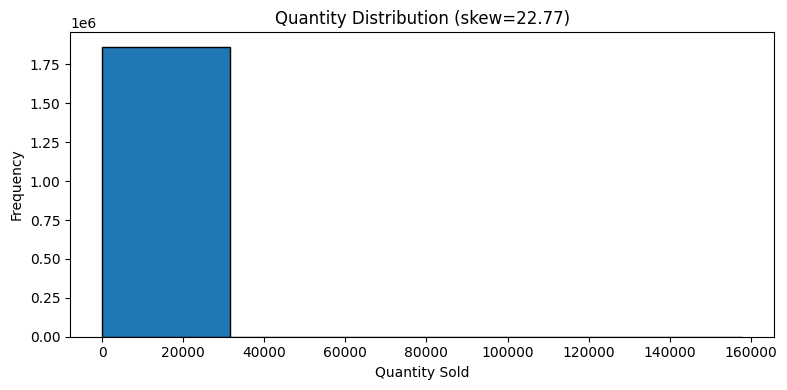

In [ ]:
# Check quantity variable skewness

quantity_skew = df_clean_sales['quantity'].skew()

# plot
plt.figure(figsize=(8, 4))
plt.hist(df_clean_sales['quantity'], bins=5, edgecolor='black')
plt.title(f'Quantity Distribution (skew={quantity_skew:.2f})')
plt.xlabel('Quantity Sold')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
df3 = df_sales[df_sales['quantity'] >= 0].copy() #remove negative values from "quantity"

In [ ]:
df3['date'] = pd.to_datetime(df3['time_key'].astype(str), format='%Y%m%d') #convert dates to datetime format

In [201]:
df3.head()

,structure_level_4,structure_level_3,structure_level_2,structure_level_1,sku,time_key,quantity,date
0,3020206,30202,302,3,3111,20230618,18.6840,2023-06-18
1,3020608,30206,302,3,3278,20240731,396.1008,2024-07-31
2,3020809,30208,302,3,3603,20230807,6.2280,2023-08-07
3,3020608,30206,302,3,4604,20230131,27.4032,2023-01-31
4,3040808,30408,304,3,3041,20230906,6.2280,2023-09-06


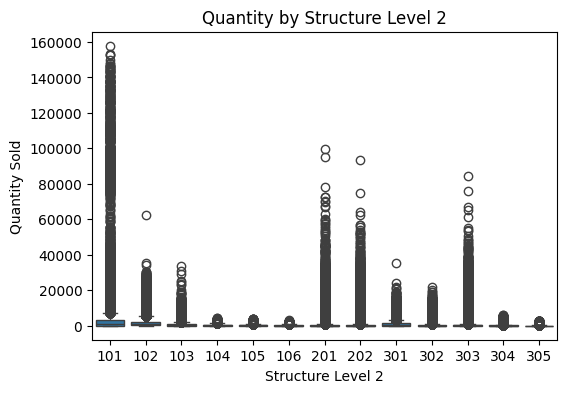

In [ ]:
# Boxplot of quantity by structure_level_2
plt.figure(figsize=(6,4))
sns.boxplot(x='structure_level_2', y='quantity', data=df3)
plt.title('Quantity by Structure Level 2')
plt.xlabel('Structure Level 2')
plt.ylabel('Quantity Sold')
plt.show()

/var/folders/vf/0_2jfjq96flc0cwpw0p4pch80000gn/T/ipykernel_23797/2318498129.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_lvl1.index.astype(str), y=counts_lvl1.values, palette=colors)


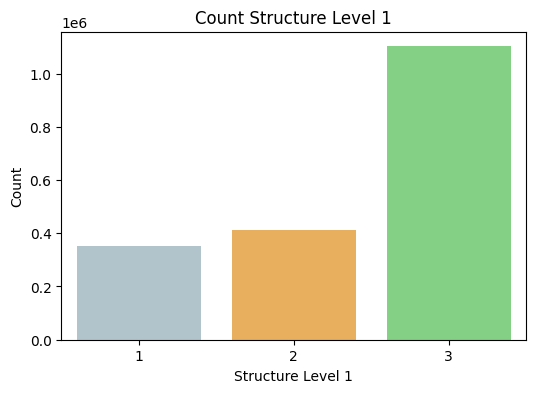

In [ ]:
# Bar chart of counts by structure_level_1
plt.figure(figsize=(6,4))
colors = [
    "#AEC6CF",  # light blue
    "#FFB347",  # light orange
    "#77DD77",  # light green
]
counts_lvl1 = df3['structure_level_1'].value_counts().sort_index()
sns.barplot(x=counts_lvl1.index.astype(str), y=counts_lvl1.values, palette=colors)
plt.title('Count Structure Level 1')
plt.xlabel('Structure Level 1')
plt.ylabel('Count')
plt.show()

/var/folders/vf/0_2jfjq96flc0cwpw0p4pch80000gn/T/ipykernel_23797/1202745433.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_lvl1.index.astype(str), y=counts_lvl1.values, palette=pastel13)


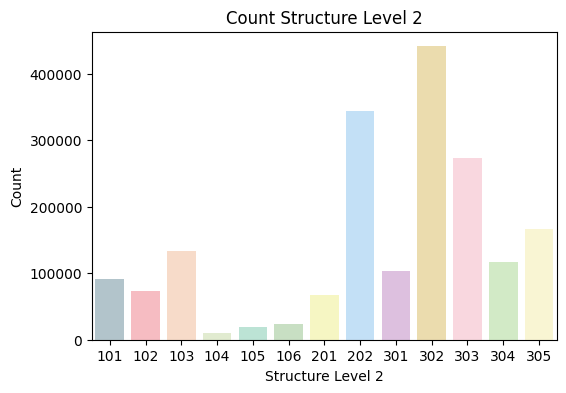

In [ ]:
# Bar chart of counts by structure_level_2
plt.figure(figsize=(6,4))
pastel13 = [
    "#AEC6CF",  # light blue
    "#FFB3BA",  # pastel pink
    "#FFDAC1",  # peach
    "#E2F0CB",  # pistachio
    "#B5EAD7",  # mint
    "#C5E3BF",  # sage
    "#FFFFBA",  # pale yellow
    "#BAE1FF",  # powder blue
    "#E2BBE4",  # lavender
    "#F5E1A4",  # soft gold
    "#FFD1DC",  # bubblegum pink
    "#D0F0C0",  # tea green
    "#FFFACD",  # lemon chiffon
]

counts_lvl1 = df3['structure_level_2'].value_counts().sort_index()
sns.barplot(x=counts_lvl1.index.astype(str), y=counts_lvl1.values, palette=pastel13)
plt.title('Count Structure Level 2')
plt.xlabel('Structure Level 2')
plt.ylabel('Count')
plt.show()

/var/folders/vf/0_2jfjq96flc0cwpw0p4pch80000gn/T/ipykernel_23797/681386988.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_qty = df3.set_index('date')['quantity'].resample('M').sum()


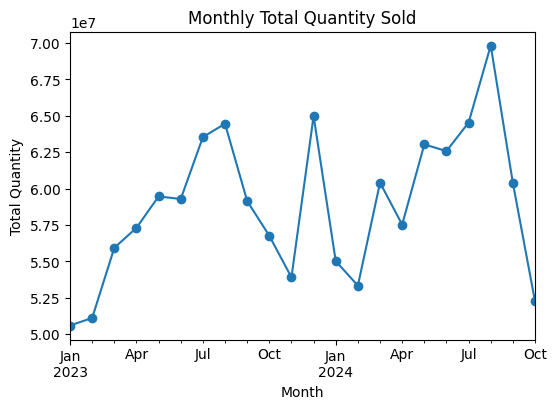

In [ ]:
# Time series of total quantity per month
monthly_qty = df3.set_index('date')['quantity'].resample('M').sum()
plt.figure(figsize=(6,4))
monthly_qty.plot(marker='o')
plt.title('Monthly Total Quantity Sold')
plt.xlabel('Month')
plt.ylabel('Total Quantity')
plt.show()

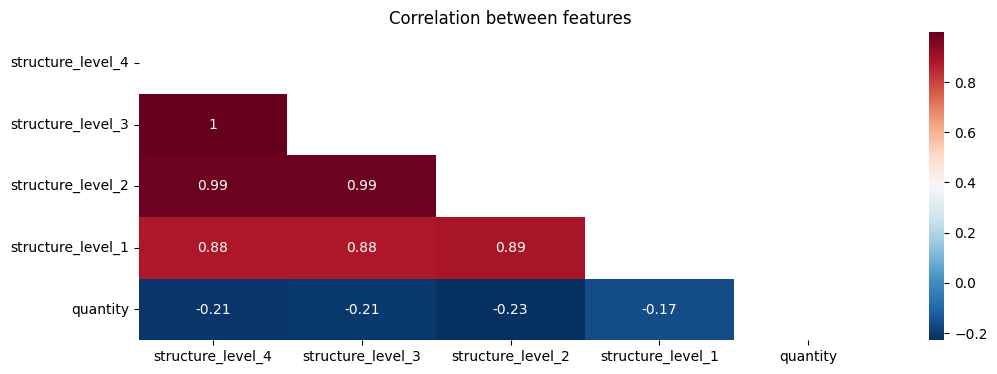

In [ ]:
# Correlation matrix - lower triangle

corr_cols = ['sku', 'time_key', 'date']
corr_matrix = df3.drop(corr_cols, axis=1).corr(method='spearman')
corr_matrix

lower_triangle_mask = np.triu(np.ones(corr_matrix.shape)).astype(bool)
cor_mat_lower = corr_matrix.mask(lower_triangle_mask)

plt.figure(figsize = (12,4))
plt.title("Correlation between features")

sns.heatmap(cor_mat_lower, 
            annot=True,
            cmap='RdBu_r');

In [196]:
df_sales.columns

Index(['structure_level_4', 'structure_level_3', 'structure_level_2',
       'structure_level_1', 'sku', 'time_key', 'quantity'],
      dtype='object')

In [50]:
df_sales.structure_level_2.nunique()

13

In [51]:
df_sales.structure_level_2.unique()

array([302, 304, 303, 202, 105, 103, 301, 305, 101, 201, 106, 102, 104])

In [ ]:
df_sales.describe() # descriptive statistics

,structure_level_4,structure_level_3,structure_level_2,structure_level_1,sku,time_key,quantity
count,1.864594e+06,1.864594e+06,1.864594e+06,1.864594e+06,1.864594e+06,1.864594e+06,1.864594e+06
mean,2.428731e+06,2.428724e+04,2.428015e+02,2.402365e+00,3.064254e+03,2.023519e+07,6.946481e+02
std,7.880273e+05,7.880271e+03,7.879493e+01,7.860546e-01,9.888995e+02,4.937769e+03,2.736481e+03
min,1.010101e+06,1.010100e+04,1.010000e+02,1.000000e+00,1.124000e+03,2.023010e+07,-2.341160e+04
25%,2.020506e+06,2.020500e+04,2.020000e+02,2.000000e+00,2.209000e+03,2.023062e+07,2.491200e+01
50%,3.020401e+06,3.020400e+04,3.020000e+02,3.000000e+00,3.085000e+03,2.023120e+07,1.108584e+02
75%,3.030709e+06,3.030700e+04,3.030000e+02,3.000000e+00,3.932000e+03,2.024052e+07,4.459248e+02
max,3.051115e+06,3.051100e+04,3.050000e+02,3.000000e+00,4.735000e+03,2.024103e+07,1.578543e+05


In [ ]:
negative_count = (df_sales['quantity'] < 0).sum() # Count negative entries

print(negative_count)

total_count = df_sales['quantity'].notna().sum()
print(total_count)

neg_pct = negative_count / total_count * 100
print(neg_pct)

292
1864594
0.015660245608427357


In [ ]:
df_sales.duplicated().sum() #check for duplicated values

np.int64(0)

In [ ]:
df_sales.isnull().sum() #check missing data

structure_level_4    0
structure_level_3    0
structure_level_2    0
structure_level_1    0
sku                  0
time_key             0
quantity             0
dtype: int64

In [ ]:
df_prices['sku'].nunique() #check skus to see if they match

3561

In [ ]:
df_sales['sku'].nunique() #check skus to see if they match

3605

In [41]:
# Check which SKUs in df_prices exist in df_sales
prices_in_sales = df_prices['sku'].isin(df_sales['sku'])
print(f"Number of SKUs in Prices dataset that are in Sales dataset: {prices_in_sales.sum()} out of {len(df_prices)}")

# To see SKUs from df_prices that are missing in df_sales:
missing_in_sales = df_prices.loc[~prices_in_sales, 'sku'].unique()
print("SKUs in Prices dataset missing in Sales dataset:", missing_in_sales)

# Check the other direction: which SKUs in df_sales exist in df_prices
sales_in_prices = df_sales['sku'].isin(df_prices['sku'])
print(f"Number of SKUs in Sales dataset that are in Prices dataset: {sales_in_prices.sum()} out of {len(df_sales)}")

# To see SKUs from df_sales that are missing in df_prices:
missing_in_prices = df_sales.loc[~sales_in_prices, 'sku'].unique()
print("SKUs in Sales dataset missing in Prices dataset:", missing_in_prices)

Number of SKUs in Prices dataset that are in Sales dataset: 3112138 out of 3112140
SKUs in Prices dataset missing in Sales dataset: [4607]
Number of SKUs in Sales dataset that are in Prices dataset: 1857544 out of 1864594
SKUs in Sales dataset missing in Prices dataset: [1369 1129 1480 1218 1519 1275 1206 3661 1322 1572 1269 1184 1252 1298
 1155 1162 2047 1276 1267 1534 1181 1215 1681 2105 1146 3031 1246 4600
 4601 1158 1137 1131 4328 1138 1127 1142 2773 1134 3867 1143 4232 2774
 1135 4233 1124]


,structure_level_4,structure_level_3,structure_level_2,structure_level_1,quantity
structure_level_4,NaN,NaN,NaN,NaN,NaN
structure_level_3,1.000000,NaN,NaN,NaN,NaN
structure_level_2,1.000000,1.000000,NaN,NaN,NaN
structure_level_1,0.999888,0.999888,0.999889,NaN,NaN
quantity,-0.148809,-0.148809,-0.148835,-0.147401,NaN


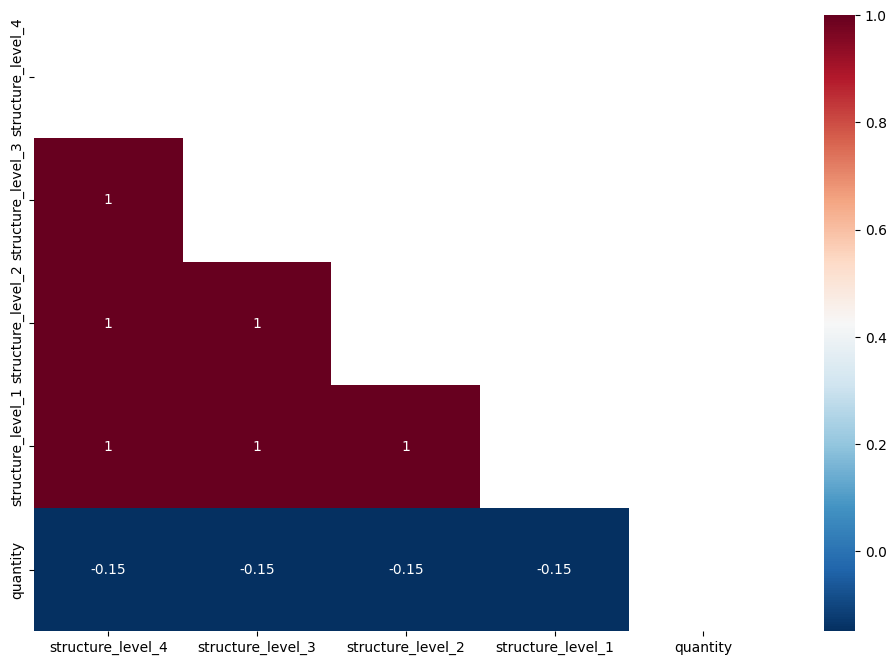

In [ ]:
# Correlation matrix
df_sales['time_key'] = pd.to_datetime(df_sales['time_key'], format='%Y%m%d') 

df_sales_no_sku = df_sales.drop(columns=['sku', 'time_key'])
cor_mat = df_sales_no_sku.corr()

lower_triangle_mask = np.triu(np.ones(cor_mat.shape)).astype(bool)
cor_mat_lower = cor_mat.mask(lower_triangle_mask)
display(cor_mat_lower)

plt.figure(figsize = (12,8))

sns.heatmap(cor_mat_lower, 
            annot=True,
            cmap='RdBu_r');


In [74]:
# Check Specific Column Range
col = 'quantity'
print(f"Min: {df_sales[col].min()}")
print(f"Max: {df_sales[col].max()}")
print(f"Range: {df_sales[col].max() - df_sales[col].min()}")

Min: -23411.600064
Max: 157854.302568
Range: 181265.902632


In [67]:
df_sales.dtypes

structure_level_4      int64
structure_level_3      int64
structure_level_2      int64
structure_level_1      int64
sku                    int64
time_key               int64
quantity             float64
dtype: object

In [ ]:
df_sales.isnull().sum() #check missing values

structure_level_4    0
structure_level_3    0
structure_level_2    0
structure_level_1    0
sku                  0
time_key             0
quantity             0
dtype: int64